In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')
# Convert dates from text to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Convert Postal Code to string (it's not a number we calculate with)
df['Postal Code'] = df['Postal Code'].astype(str)

# Confirm the fixes
print(df[['Order Date', 'Ship Date', 'Postal Code']].dtypes)

Order Date     datetime64[ns]
Ship Date      datetime64[ns]
Postal Code            object
dtype: object


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')
# Check the shape
print("Rows & Columns:", df.shape)

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

Rows & Columns: (9994, 21)

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')

# First look at the data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(10)

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [4]:
from sqlalchemy import create_engine

# Replace these with your actual PostgreSQL credentials
DB_USER = "postgres"        # your postgres username
DB_PASSWORD = "paok2001"  # your postgres password
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "sales_analysis"  # we will create this database

# Create connection
engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

print("Connected successfully! ✅")

Connected successfully! ✅


In [15]:
query3 = """
SELECT 
    "Customer Name",
    ROUND(SUM("Sales")::numeric, 2) AS total_sales,
    ROUND(SUM("Profit")::numeric, 2) AS total_profit,
    COUNT(*) AS total_orders
FROM orders
GROUP BY "Customer Name"
ORDER BY total_sales DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query3, engine)
top_customers

,Customer Name,total_sales,total_profit,total_orders
0,Sean Miller,25043.05,-1980.74,15
1,Tamara Chand,19052.22,8981.32,12
2,Raymond Buch,15117.34,6976.10,18
3,Tom Ashbrook,14595.62,4703.79,10
4,Adrian Barton,14473.57,5444.81,20
5,Ken Lonsdale,14175.23,806.86,29
6,Sanjit Chand,14142.33,5757.41,22
7,Hunter Lopez,12873.30,5622.43,11
8,Sanjit Engle,12209.44,2650.68,19
9,Christopher Conant,12129.07,2177.05,11


In [30]:
query4 = """
SELECT 
    "Order Year",
    ROUND(SUM("Sales")::numeric, 2) AS total_sales,
    ROUND(SUM("Profit")::numeric, 2) AS total_profit,
    COUNT(*) AS total_orders
FROM orders
GROUP BY "Order Year"
ORDER BY "Order Year" ASC;
"""

yearly_sales = pd.read_sql(query4, engine)
yearly_sales

ProgrammingError: (psycopg2.errors.UndefinedColumn) column "Order Year" does not exist
LINE 3:     "Order Year",
            ^

[SQL: 
SELECT 
    "Order Year",
    ROUND(SUM("Sales")::numeric, 2) AS total_sales,
    ROUND(SUM("Profit")::numeric, 2) AS total_profit,
    COUNT(*) AS total_orders
FROM orders
GROUP BY "Order Year"
ORDER BY "Order Year" ASC;
]
(Background on this error at: https://sqlalche.me/e/20/f405)

In [31]:
query5 = """
SELECT 
    "Order Month",
    "Order Month Name",
    ROUND(SUM("Sales")::numeric, 2) AS total_sales,
    ROUND(SUM("Profit")::numeric, 2) AS total_profit
FROM orders
GROUP BY "Order Month", "Order Month Name"
ORDER BY "Order Month" ASC;
"""

monthly_sales = pd.read_sql(query5, engine)
monthly_sales

ProgrammingError: (psycopg2.errors.UndefinedColumn) column "Order Month" does not exist
LINE 3:     "Order Month",
            ^

[SQL: 
SELECT 
    "Order Month",
    "Order Month Name",
    ROUND(SUM("Sales")::numeric, 2) AS total_sales,
    ROUND(SUM("Profit")::numeric, 2) AS total_profit
FROM orders
GROUP BY "Order Month", "Order Month Name"
ORDER BY "Order Month" ASC;
]
(Background on this error at: https://sqlalche.me/e/20/f405)

In [20]:
# Set the style for all charts
plt.style.use('dark_background')
sns.set_palette("husl")

# Make charts look bigger and cleaner
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

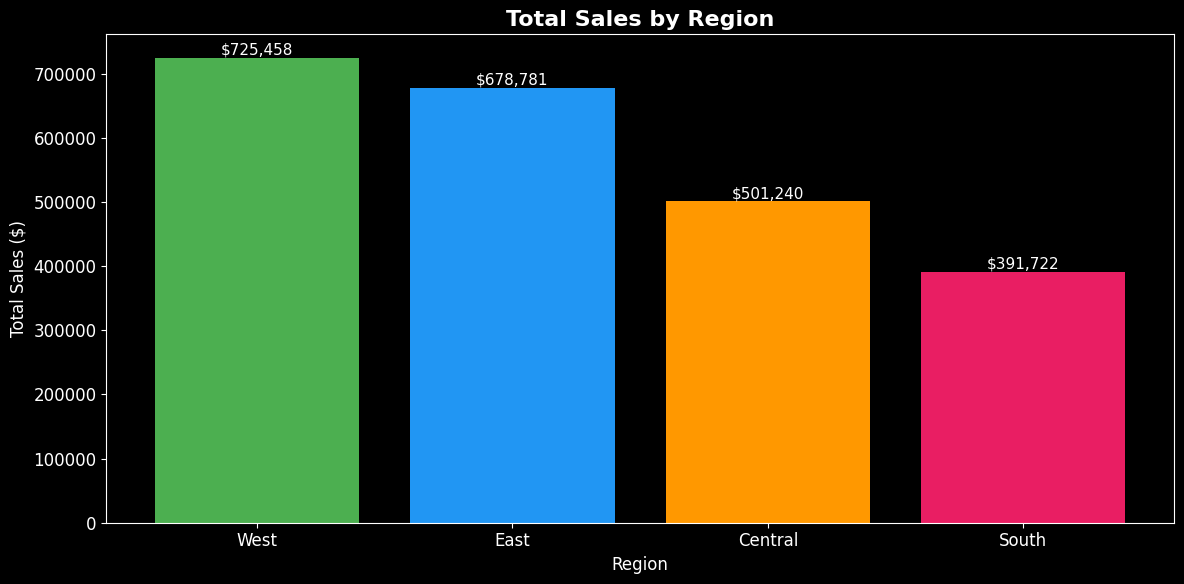

In [24]:
fig, ax = plt.subplots()

bars = ax.bar(region_sales['Region'], region_sales['total_sales'], color=['#4CAF50', '#2196F3', '#FF9800', '#E91E63'])

# Add value labels on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f"${bar.get_height():,.0f}", ha='center', fontsize=11)

ax.set_title('Total Sales by Region', fontsize=16, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales ($)')

plt.tight_layout()
plt.savefig('../data/sales_by_region.png', dpi=150)
plt.show()

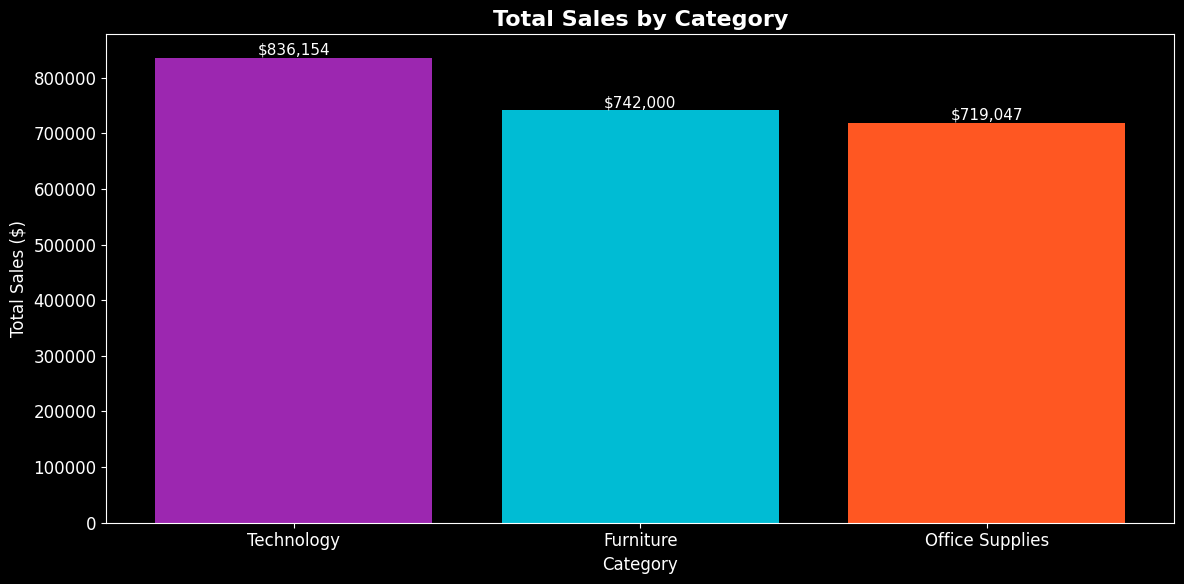

In [25]:
fig, ax = plt.subplots()

bars = ax.bar(category_sales['Category'], category_sales['total_sales'], 
              color=['#9C27B0', '#00BCD4', '#FF5722'])

# Add value labels on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f"${bar.get_height():,.0f}", ha='center', fontsize=11)

ax.set_title('Total Sales by Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales ($)')

plt.tight_layout()
plt.savefig('../data/sales_by_category.png', dpi=150)
plt.show()

NameError: name 'yearly_sales' is not defined

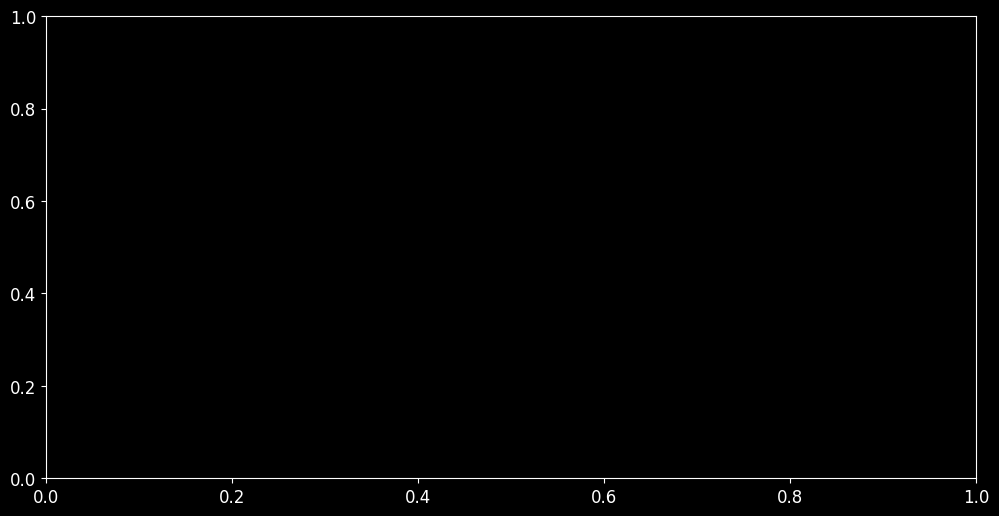

In [26]:
fig, ax = plt.subplots()

ax.plot(yearly_sales['Order Year'], yearly_sales['total_sales'], 
        marker='o', linewidth=3, markersize=8, color='#4CAF50')

# Add value labels on each point
for i, row in yearly_sales.iterrows():
    ax.text(row['Order Year'], row['total_sales'] + 8000,
            f"${row['total_sales']:,.0f}", ha='center', fontsize=11)

ax.set_title('Yearly Sales Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales ($)')
ax.set_xticks([2014, 2015, 2016, 2017])

plt.tight_layout()
plt.savefig('../data/yearly_sales_trend.png', dpi=150)
plt.show()

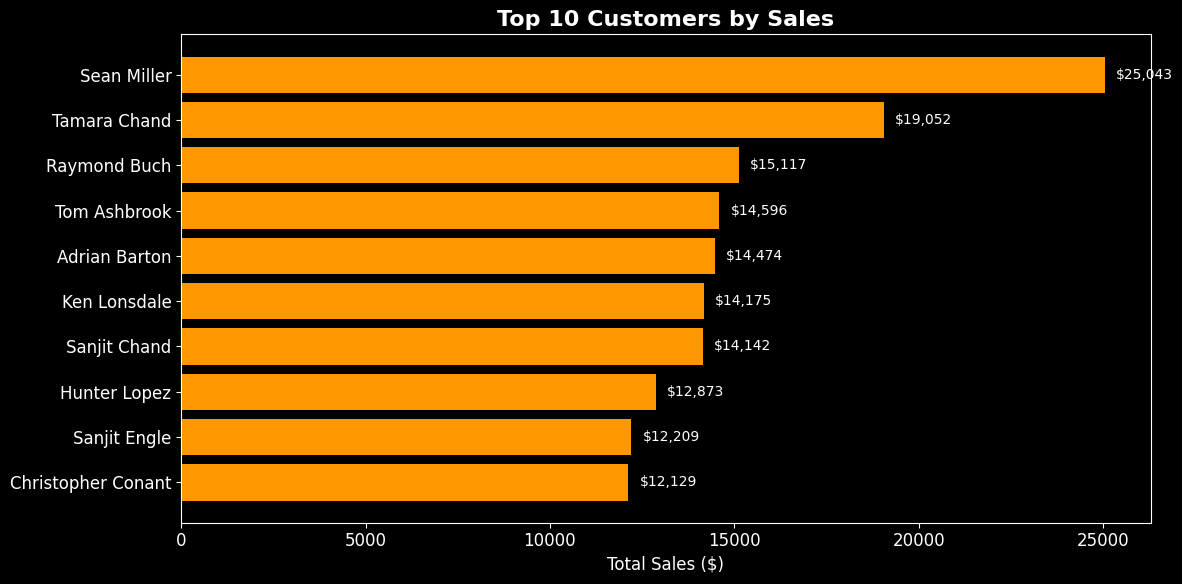

In [27]:
fig, ax = plt.subplots()

bars = ax.barh(top_customers['Customer Name'], top_customers['total_sales'],
               color='#FF9800')

# Add value labels
for bar in bars:
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f"${bar.get_width():,.0f}", va='center', fontsize=10)

ax.set_title('Top 10 Customers by Sales', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../data/top_customers.png', dpi=150)
plt.show()

NameError: name 'monthly_sales' is not defined

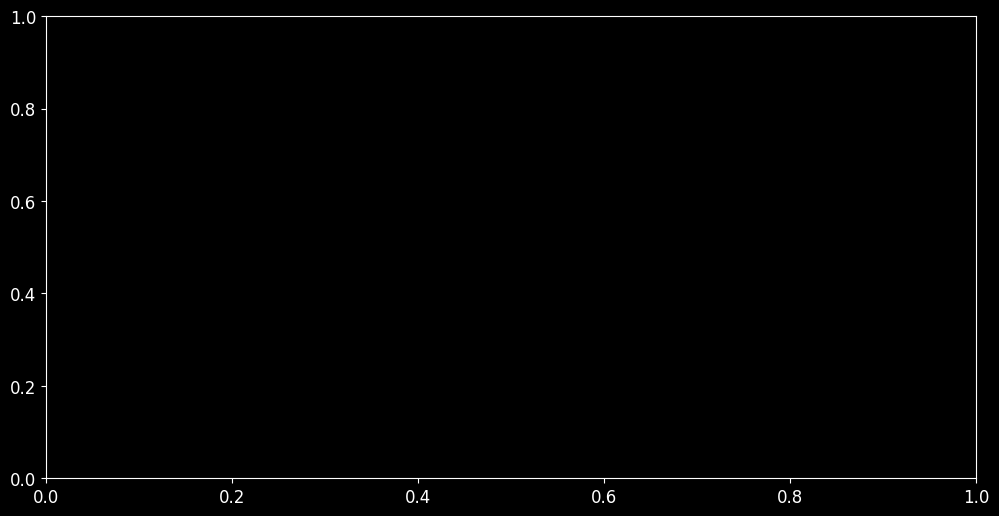

In [28]:
fig, ax = plt.subplots()

ax.plot(monthly_sales['Order Month Name'], monthly_sales['total_sales'],
        marker='o', linewidth=3, markersize=8, color='#2196F3')

# Add value labels on each point
for i, row in monthly_sales.iterrows():
    ax.text(i, row['total_sales'] + 5000,
            f"${row['total_sales']:,.0f}", ha='center', fontsize=9)

ax.set_title('Monthly Sales Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../data/monthly_sales_trend.png', dpi=150)
plt.show()

In [10]:
# Extract Year and Month from Order Date
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%B')

# Calculate how many days it took to ship
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Confirm new columns
print(df[['Order Date', 'Ship Date', 'Order Year', 'Order Month', 'Order Month Name', 'Days to Ship']].head())

AttributeError: Can only use .dt accessor with datetimelike values

In [6]:
# Load the cleaned dataframe into PostgreSQL as a table
df.to_sql('orders', engine, if_exists='replace', index=False)

print("Table created successfully! ✅")
print(f"Loaded {len(df)} rows into the 'orders' table")

Table created successfully! ✅
Loaded 9994 rows into the 'orders' table


In [8]:
query1 = """
SELECT 
    "Region",
    ROUND(SUM("Sales")::numeric, 2) AS total_sales,
    ROUND(SUM("Profit")::numeric, 2) AS total_profit,
    COUNT(*) AS total_orders
FROM orders
GROUP BY "Region"
ORDER BY total_sales DESC;
"""

region_sales = pd.read_sql(query1, engine)
region_sales

,Region,total_sales,total_profit,total_orders
0,West,725457.82,108418.45,3203
1,East,678781.24,91522.78,2848
2,Central,501239.89,39706.36,2323
3,South,391721.91,46749.43,1620


In [9]:
query2 = """
SELECT 
    "Category",
    ROUND(SUM("Sales")::numeric, 2) AS total_sales,
    ROUND(SUM("Profit")::numeric, 2) AS total_profit,
    COUNT(*) AS total_orders
FROM orders
GROUP BY "Category"
ORDER BY total_sales DESC;
"""

category_sales = pd.read_sql(query2, engine)
category_sales

,Category,total_sales,total_profit,total_orders
0,Technology,836154.03,145454.95,1847
1,Furniture,741999.80,18451.27,2121
2,Office Supplies,719047.03,122490.80,6026
